# Импорт библиотек

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Подготовка MNIST

In [30]:
(x_train_img, y_train), (x_test_img, y_test) = keras.datasets.mnist.load_data()

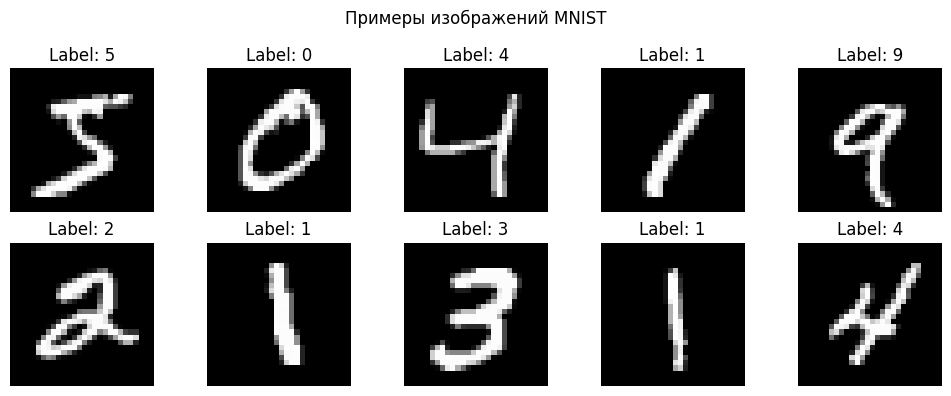

In [31]:
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train_img[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

Нормализация значений пикселей в диапазон [0, 1]

In [32]:
x_train = x_train_img.astype("float32") / 255.0
x_test = x_test_img.astype("float32") / 255.0

Преобразуем изображения 28x28 в векторы длины 784

In [33]:
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [34]:
print("Размер обучающей выборки:", x_train.shape, y_train.shape)
print("Размер тестовой выборки:", x_test.shape, y_test.shape)

Размер обучающей выборки: (60000, 784) (60000,)
Размер тестовой выборки: (10000, 784) (10000,)


# Обучение

Функция создания модели

In [35]:
def build_mlp(hidden_layers):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    for units in hidden_layers:
        model.add(layers.Dense(units, activation="relu"))

    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

Несколько небольших персептронов

In [36]:
architectures = {
    "Model_1_2layers_64": [64],
    "Model_2_3layers_128_64": [128, 64],
    "Model_3_4layers_256_128_64": [256, 128, 64],
    "Model_4_3layers_32_32": [32, 32],
    "Model_5_4layers_128_64_32": [128, 64, 32]
}

Обучение и оценка моделей

In [37]:
results = []
histories = {}
trained_models = {}
for name, hidden_layers in architectures.items():
    print(f"\nОбучение {name} -> {hidden_layers}")

    model = build_mlp(hidden_layers)

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=128,
        validation_split=0.1,
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    results.append({
        "model": name,
        "hidden_layers": hidden_layers,
        "test_loss": test_loss,
        "test_accuracy": test_acc
    })

    histories[name] = history.history
    trained_models[name] = model


Обучение Model_1_2layers_64 -> [64]
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 942us/step - accuracy: 0.8807 - loss: 0.4375 - val_accuracy: 0.9460 - val_loss: 0.1972
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 844us/step - accuracy: 0.9389 - loss: 0.2125 - val_accuracy: 0.9610 - val_loss: 0.1504
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 908us/step - accuracy: 0.9536 - loss: 0.1624 - val_accuracy: 0.9670 - val_loss: 0.1223
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - accuracy: 0.9621 - loss: 0.1316 - val_accuracy: 0.9707 - val_loss: 0.1105
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 927us/step - accuracy: 0.9676 - loss: 0.1122 - val_accuracy: 0.9727 - val_loss: 0.1020

Обучение Model_2_3layers_128_64 -> [128, 64]
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8998 - loss: 0.3550 - val_accuracy: 0.9590 - val_loss: 0.1493
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9582 - loss: 0.1423 - val_accuracy: 0.9717 - val_loss: 0.1037
Epoch 3/5
422/422 

In [38]:
print("\nИтоговые результаты:")
for r in results:
    print(
        f"{r['model']}: hidden_layers={r['hidden_layers']}, "
        f"test_loss={r['test_loss']:.4f}, test_accuracy={r['test_accuracy']:.4f}"
    )


Итоговые результаты:
Model_1_2layers_64: hidden_layers=[64], test_loss=0.1165, test_accuracy=0.9663
Model_2_3layers_128_64: hidden_layers=[128, 64], test_loss=0.0904, test_accuracy=0.9728
Model_3_4layers_256_128_64: hidden_layers=[256, 128, 64], test_loss=0.0734, test_accuracy=0.9785
Model_4_3layers_32_32: hidden_layers=[32, 32], test_loss=0.1550, test_accuracy=0.9552
Model_5_4layers_128_64_32: hidden_layers=[128, 64, 32], test_loss=0.0816, test_accuracy=0.9752


Все модели показали высокую точность и Model_3_4layers_256_128_64 показала лучший результат

Визуализируем результаты

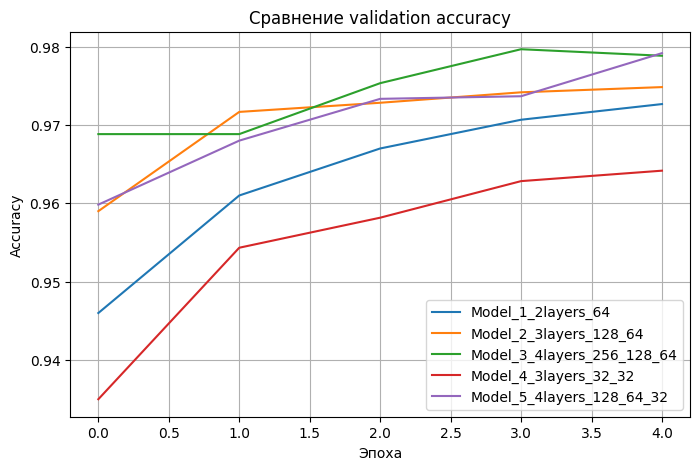

In [39]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history["val_accuracy"], label=name)
plt.title("Сравнение validation accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Видно, что:
- Рост качества у всех моделей
- Лучшая динамика у глубоких моделей
- Слабая архитектура 32_32
- Насыщение к 4–5 эпохе

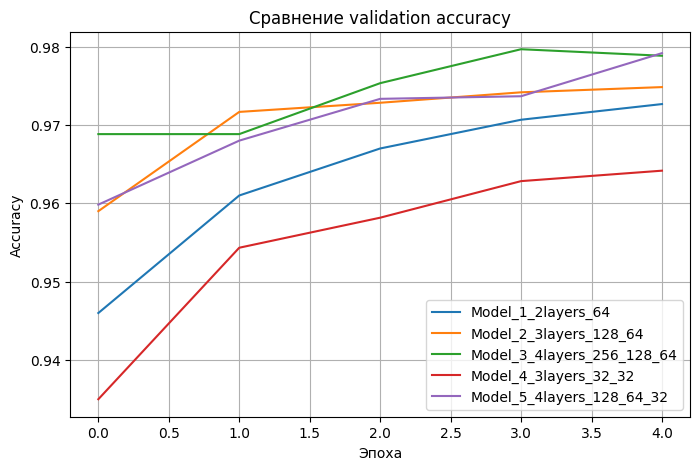

In [40]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history["val_accuracy"], label=name)
plt.title("Сравнение validation accuracy")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

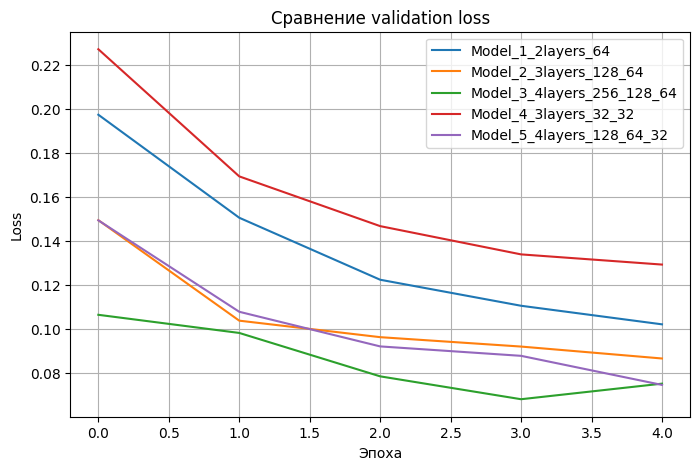

In [41]:
plt.figure(figsize=(8, 5))
for name, history in histories.items():
    plt.plot(history["val_loss"], label=name)
plt.title("Сравнение validation loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

Видно, что:
- У всех моделей loss в целом уменьшается – обучение устойчивое, оптимизация проходит нормально, модель всё лучше согласуется с правильными ответами
- У Model_3_4layers_256_128_64 минимальный val_loss среди всех или один из минимальных почти на всех эпохах
- Небольшое колебание у лучшей модели в конце
- У Model_4_3layers_32_32 loss самый большой почти на всём протяжении обучения, что согласуется с её низкой точностью

In [42]:
model_names = [r["model"] for r in results]
accuracies = [r["test_accuracy"] for r in results]

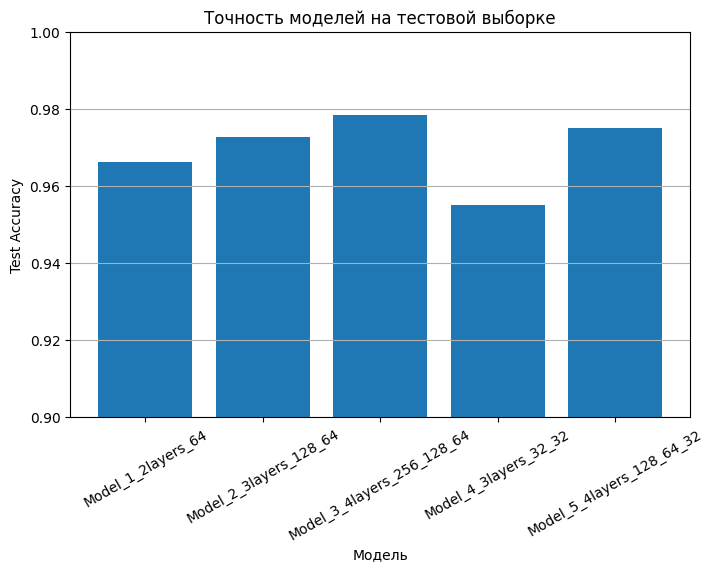

In [43]:
plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies)
plt.title("Точность моделей на тестовой выборке")
plt.xlabel("Модель")
plt.ylabel("Test Accuracy")
plt.ylim(0.9, 1.0)
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

**Вывод**:
- Увеличение числа нейронов и глубины помогает, но важна не только глубина, а ещё и ширина
- Самая удачная архитектура из проверенных – [256, 128, 64]

In [44]:
best_result = max(results, key=lambda x: x["test_accuracy"])
best_name = best_result["model"]
best_model = trained_models[best_name]

In [45]:
print("\nЛучшая модель:")
print(best_result)


Лучшая модель:
{'model': 'Model_3_4layers_256_128_64', 'hidden_layers': [256, 128, 64], 'test_loss': 0.07338988035917282, 'test_accuracy': 0.9785000085830688}


Матрица ошибок

In [46]:
y_pred_probs = best_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 411us/step


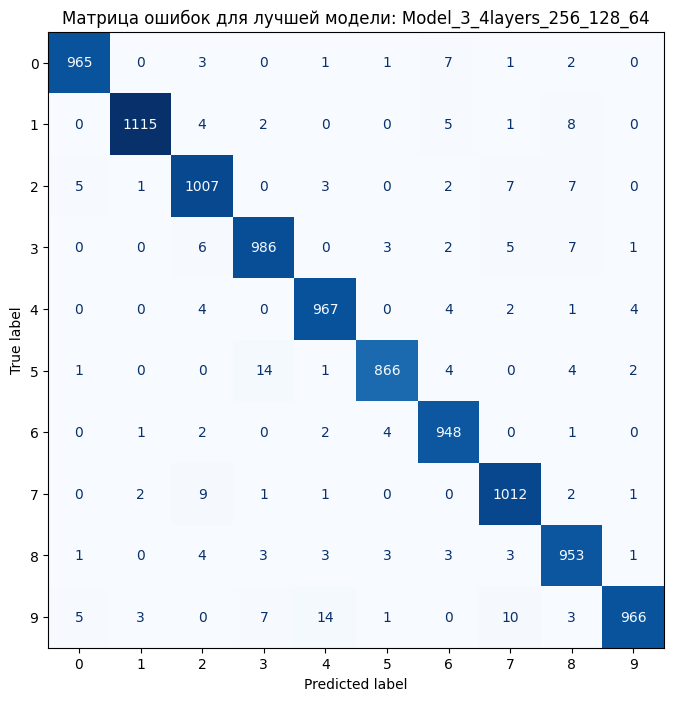

In [47]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Матрица ошибок для лучшей модели: {best_name}")
plt.show()

In [48]:
wrong_idx = np.where(y_pred != y_test)[0]

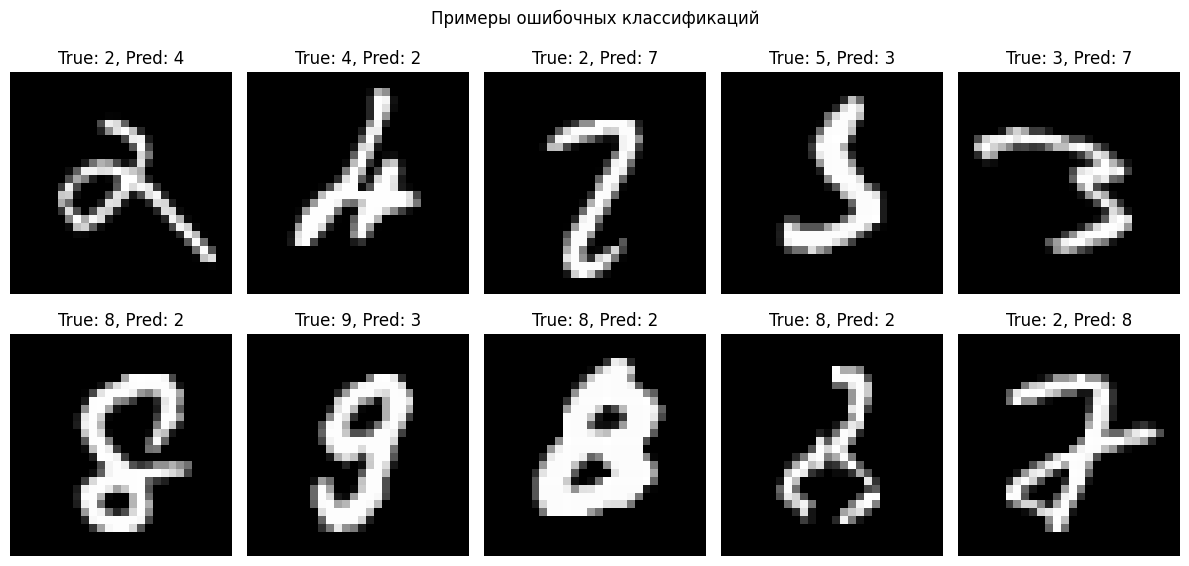

In [50]:
plt.figure(figsize=(12, 6))
for i, idx in enumerate(wrong_idx[:10]):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test_img[idx], cmap="gray")
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    plt.axis("off")
plt.suptitle("Примеры ошибочных классификаций")
plt.tight_layout()
plt.show()

**Вывод**:
- Особенно трудные пары – 2 и 7, 2 и 8, 4 и 2, 5 и 3, 3 и 7, 9 и 3 / 4